In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
path_data_dir = Path("../../data/matrices").resolve()
path_data_dir

PosixPath('/home/bugra/Workspace/C/HetHypPar_rewrite/data/matrices')

In [3]:
path_results = list((path_data_dir.glob("*/log/*")))
path_results[:10]

[PosixPath('/home/bugra/Workspace/C/HetHypPar_rewrite/data/matrices/li/log/benchmark_results_20251110_202648_79000909940b2c27.tsv'),
 PosixPath('/home/bugra/Workspace/C/HetHypPar_rewrite/data/matrices/ted_A_unscaled/log/benchmark_results_20251110_205035_79000909940b2c27.tsv'),
 PosixPath('/home/bugra/Workspace/C/HetHypPar_rewrite/data/matrices/Chebyshev4/log/benchmark_results_20251110_193712_79000909940b2c27.tsv'),
 PosixPath('/home/bugra/Workspace/C/HetHypPar_rewrite/data/matrices/g7jac080sc/log/benchmark_results_20251110_201753_79000909940b2c27.tsv'),
 PosixPath('/home/bugra/Workspace/C/HetHypPar_rewrite/data/matrices/venkat50/log/benchmark_results_20251110_205528_79000909940b2c27.tsv'),
 PosixPath('/home/bugra/Workspace/C/HetHypPar_rewrite/data/matrices/sme3Dc/log/benchmark_results_20251110_204843_79000909940b2c27.tsv'),
 PosixPath('/home/bugra/Workspace/C/HetHypPar_rewrite/data/matrices/webbase-1M/log/benchmark_results_20251110_205753_79000909940b2c27.tsv'),
 PosixPath('/home/bugra

In [4]:
df = pd.read_csv(path_results[0],sep="\t")
df.drop(df.index[1], inplace=True)
cols = df["partition_file"].values

def get_speedups(path_res : Path):
    mydf = pd.read_csv(path_res,sep="\t")
    mydf.drop(df.index[1], inplace=True)
    mydf["speedup"] = mydf["spmv"] / mydf["spmv"].min()
    return mydf["speedup"].values

results = [
    get_speedups(pres) for pres in path_results
]

In [5]:
cols

array(['cpu', 'w100_16_i1.part', 'w100_16_i10.part', 'w100_16_i3.part',
       'w150_16_i1.part', 'w150_16_i10.part', 'w150_16_i3.part',
       'w200_16_i1.part', 'w200_16_i10.part', 'w200_16_i3.part',
       'w219_16_i1.part', 'w219_16_i10.part', 'w219_16_i3.part',
       'w250_16_i1.part', 'w250_16_i10.part', 'w250_16_i3.part',
       'w300_16_i1.part', 'w300_16_i10.part', 'w300_16_i3.part'],
      dtype=object)

In [6]:
ranks = pd.DataFrame(results, columns=cols)
ranks

,cpu,w100_16_i1.part,w100_16_i10.part,w100_16_i3.part,w150_16_i1.part,w150_16_i10.part,w150_16_i3.part,w200_16_i1.part,w200_16_i10.part,w200_16_i3.part,w219_16_i1.part,w219_16_i10.part,w219_16_i3.part,w250_16_i1.part,w250_16_i10.part,w250_16_i3.part,w300_16_i1.part,w300_16_i10.part,w300_16_i3.part
0,6.580634,1.628521,1.483451,1.528169,1.184155,1.155282,1.155634,1.034507,1.022535,1.000000,1.056690,1.052465,1.054577,1.084859,1.101761,1.069718,1.151408,1.096127,1.105282
1,5.719848,3.078822,1.379867,1.360874,1.157645,1.207028,1.130104,1.108262,1.113010,1.000000,1.162393,1.149098,1.106363,1.119658,1.058879,1.075024,1.080722,1.048433,1.160494
2,11.622989,1.000000,8.651395,8.458461,8.090511,8.145693,8.950214,8.744248,8.592038,7.632254,8.480859,7.504480,8.859194,7.238750,7.349725,7.130422,6.926288,6.555182,7.128283
3,4.183844,2.318245,1.444290,1.238162,1.099582,1.199861,1.215181,1.059889,1.092618,1.000000,1.029944,1.024373,1.060585,1.105153,1.045961,1.032033,1.082173,1.012535,1.046657
4,10.703513,1.491574,1.623250,1.616967,1.277921,1.273922,1.284776,1.054270,1.024850,1.070266,1.000000,1.016567,1.023422,1.035418,1.035990,1.031991,1.065124,1.068266,1.065981
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,5.911315,2.623089,1.467890,1.449541,1.192661,1.141437,1.166667,1.052752,1.038226,1.058869,1.017584,1.001529,1.024465,1.015291,1.005352,1.000000,1.037462,1.049694,1.030581
246,6.053828,3.857656,1.387560,1.458134,1.186603,1.198565,1.160287,1.000000,1.026316,1.022727,1.032297,1.015550,1.049043,1.011962,1.019139,1.022727,1.007177,1.046651,1.050239
247,6.010782,4.175202,1.181941,1.159030,1.040431,1.000000,1.035040,1.037736,1.016173,1.028302,1.066038,1.082210,1.056604,1.060647,1.051213,1.082210,1.133423,1.109164,1.111860
248,4.673684,2.203289,1.411184,1.520395,1.261184,1.194737,1.150000,1.165132,1.127632,1.217763,1.037500,1.069079,1.061184,1.000000,1.025658,1.060526,1.079605,1.016447,1.060526


In [7]:
np.where(ranks["w200_16_i3.part"].values > 2.0)

(array([  2,   6,  11,  12,  14,  21,  23,  28,  32,  33,  39,  46,  47,
         50,  52,  58,  60,  63,  66,  67,  71,  81,  85,  86,  87,  88,
         95,  98, 113, 114, 115, 116, 120, 127, 130, 132, 133, 137, 139,
        140, 141, 144, 145, 148, 152, 155, 158, 160, 164, 169, 170, 178,
        184, 188, 191, 193, 198, 202, 212, 218, 220, 222, 223, 226, 230,
        234, 244]),)

In [8]:
df_sorted = pd.DataFrame({col: np.sort(ranks[col].values) for col in ranks.columns})
df_sorted

,cpu,w100_16_i1.part,w100_16_i10.part,w100_16_i3.part,w150_16_i1.part,w150_16_i10.part,w150_16_i3.part,w200_16_i1.part,w200_16_i10.part,w200_16_i3.part,w219_16_i1.part,w219_16_i10.part,w219_16_i3.part,w250_16_i1.part,w250_16_i10.part,w250_16_i3.part,w300_16_i1.part,w300_16_i10.part,w300_16_i3.part
0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
1,1.000000,1.000000,1.007759,1.015518,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2,1.000000,1.000000,1.051958,1.061217,1.000000,1.000000,1.002038,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
3,1.563140,1.000000,1.058364,1.064398,1.002568,1.005858,1.004281,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
4,1.634103,1.000000,1.060484,1.066716,1.003397,1.008902,1.005922,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,12.460851,6.150562,9.330683,8.575544,8.830498,8.242088,8.956091,8.744248,8.592038,8.080026,8.480859,8.606915,8.614914,8.542404,7.516847,8.245614,8.495791,7.854019,7.844840
246,12.646237,7.309392,10.339200,9.264112,10.224489,8.963672,10.211345,10.038760,8.702410,8.696213,8.604307,10.123343,8.859194,10.034780,7.955558,8.509601,9.975085,8.500652,8.436688
247,12.794944,16.974194,13.296774,10.370645,12.070968,10.208739,12.238710,12.470968,10.074437,10.029483,10.101286,11.941935,10.082789,12.780645,8.483011,9.928029,12.664516,10.020739,9.978616
248,13.284827,23.070175,16.184211,15.701754,15.771930,11.864516,15.991228,16.236842,15.166667,12.832258,13.800000,14.700000,12.316129,15.657895,9.927693,11.638710,15.885965,15.149123,14.631579


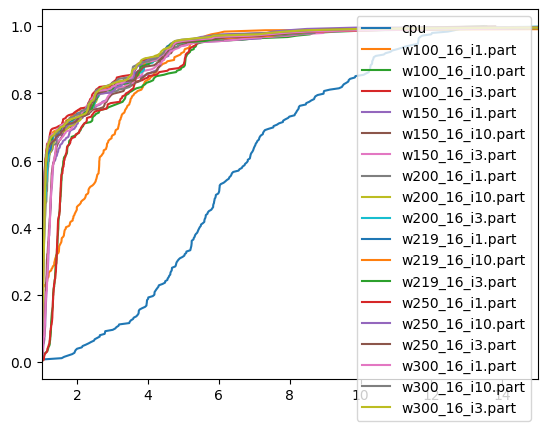

In [11]:
# y from 0 to 1 (top to bottom)
y = np.linspace(0, 1, len(df_sorted))

plt.figure()
for col in df_sorted.columns:
    plt.plot(df_sorted[col], y, label=col)

# normal y-axis (not inverted)
plt.xlim(1, 15)  # left=1, right=5
# plt.xlabel("Value")
# plt.ylabel("Normalized position (0→1)")
plt.legend()
plt.savefig("sorted_lines.png", dpi=300, bbox_inches="tight")
plt.show()